# Visualize concordance FITS

This notebook loads a concordance FITS product, groups extensions like `NISP_H.DRA`, `NISP_H.DDE`, and `NISP_H.COV`, and builds quick-look plots plus a compact summary table.

It defaults to the global FITS currently under `checkpoints/astro_v7_centernet_200tiles/`, but you can point `FITS_PATH` at any similar product.


In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from astropy.io import fits
from astropy.table import Table
from astropy.wcs import WCS
from scipy.ndimage import gaussian_filter

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["image.origin"] = "lower"


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "README.md").exists() and (candidate / "io").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
FITS_PATH = REPO_ROOT / "checkpoints/astro_v7_centernet_200tiles/global_concordance.fits"

if not FITS_PATH.exists():
    raise FileNotFoundError(
        f"Could not find FITS file at {FITS_PATH}. Update FITS_PATH in this cell."
    )

print(FITS_PATH)


/home/shemmati/Work/Projects/JAISP/checkpoints/astro_v7_centernet_200tiles/global_concordance.fits


In [7]:
with fits.open(FITS_PATH) as hdul:
    primary_header = hdul[0].header.copy()
    grouped = {}
    hdu_rows = []

    for idx, hdu in enumerate(hdul):
        shape = None if hdu.data is None else tuple(int(x) for x in hdu.data.shape)
        hdu_rows.append((idx, hdu.name, type(hdu).__name__, shape))

        if idx == 0 or not hdu.name or "." not in hdu.name:
            continue

        prefix, field = hdu.name.rsplit(".", 1)
        field = field.upper()
        grouped.setdefault(prefix, {})[field] = {
            "data": None if hdu.data is None else np.array(hdu.data, dtype=float),
            "header": hdu.header.copy(),
        }

grouped = {
    name: fields
    for name, fields in grouped.items()
    if {"DRA", "DDE"}.issubset(fields)
}

interesting_keys = ["CONCRDNC", "SOLVER", "DSTEP", "NAXIS"]
for key in interesting_keys:
    if key in primary_header:
        print(f"{key}: {primary_header[key]}")

print(f"Found {len(grouped)} grouped products.")
display(Table(rows=hdu_rows, names=("idx", "name", "type", "shape")))


CONCRDNC: True
NAXIS: 0
Found 9 grouped products.


idx,name,type,shape
int64,str10,str10,object
0,PRIMARY,PrimaryHDU,None
1,NISP_H.DRA,ImageHDU,"(1827, 1274)"
2,NISP_H.DDE,ImageHDU,"(1827, 1274)"
3,NISP_H.COV,ImageHDU,"(1827, 1274)"
4,NISP_J.DRA,ImageHDU,"(1827, 1274)"
5,NISP_J.DDE,ImageHDU,"(1827, 1274)"
6,NISP_J.COV,ImageHDU,"(1827, 1274)"
7,NISP_Y.DRA,ImageHDU,"(1827, 1274)"
8,NISP_Y.DDE,ImageHDU,"(1827, 1274)"


In [8]:
MAS_PER_ARCSEC = 1000.0
COVERAGE_GOOD_PX = 100.0
GLOBAL_CLIP_ARCSEC = 0.3
MAG_RANGE_HI_PCT = 98.5
DENSITY_SIGMA_PX = 12.0
DENSITY_RANGE_LO_PCT = 12.0
DENSITY_RANGE_HI_PCT = 99.7
QUIVER_STRIDE = 64
QUIVER_ARROW_PIXELS = QUIVER_STRIDE * 0.90
CACHE_PATH = FITS_PATH.parent / "predictions_cache.npz"
PREDICTION_CACHE = np.load(CACHE_PATH, allow_pickle=True) if CACHE_PATH.exists() else None


def finite_values(array):
    values = np.asarray(array, dtype=float)
    return values[np.isfinite(values)]


def ordered_names(names):
    preferred = ["NISP_H", "NISP_J", "NISP_Y", "U", "G", "R", "I", "Z", "Y"]
    extras = sorted(name for name in names if name not in preferred)
    return [name for name in preferred if name in names] + extras


def cache_key_for_group(name):
    return f"nisp_{name.split('_', 1)[1]}" if name.startswith("NISP_") else name.lower()


def cached_points_for_group(name, clip_arcsec=GLOBAL_CLIP_ARCSEC):
    if PREDICTION_CACHE is None:
        return None

    key = cache_key_for_group(name)
    ra_key = f"{key}_ra"
    if ra_key not in PREDICTION_CACHE:
        return None

    ra = np.asarray(PREDICTION_CACHE[f"{key}_ra"], dtype=float)
    dec = np.asarray(PREDICTION_CACHE[f"{key}_dec"], dtype=float)
    pred = np.asarray(PREDICTION_CACHE[f"{key}_pred"], dtype=float)
    keep = np.isfinite(ra) & np.isfinite(dec) & np.all(np.isfinite(pred), axis=1)

    if clip_arcsec is not None:
        pred_mag = np.hypot(pred[:, 0], pred[:, 1])
        keep &= pred_mag <= float(clip_arcsec)

    return {
        "ra": ra[keep],
        "dec": dec[keep],
        "n_total": int(len(ra)),
        "n_used": int(keep.sum()),
    }


def coverage_mask(cov, max_cov=COVERAGE_GOOD_PX):
    if cov is None:
        return None
    cov = np.asarray(cov, dtype=float)
    return (~np.isfinite(cov)) | (cov > max_cov)


def mask_by_coverage(image, cov, max_cov=COVERAGE_GOOD_PX):
    image = np.asarray(image, dtype=float)
    mask = coverage_mask(cov, max_cov=max_cov)
    if mask is None:
        return image
    return np.ma.masked_where(mask, image)


def offset_magnitude(dra, dde, cov=None):
    magnitude = np.hypot(np.asarray(dra, dtype=float), np.asarray(dde, dtype=float))
    return mask_by_coverage(magnitude, cov)


def quiver_samples(dra, dde, cov=None, stride=QUIVER_STRIDE, reference_mas=1.0, min_mas=0.0):
    dra = np.asarray(dra, dtype=float)
    dde = np.asarray(dde, dtype=float)

    x = np.arange(stride // 2, dra.shape[1], stride)
    y = np.arange(stride // 2, dra.shape[0], stride)
    xx, yy = np.meshgrid(x, y)

    sampled_dra = dra[yy, xx]
    sampled_dde = dde[yy, xx]
    sampled_mag = np.hypot(sampled_dra, sampled_dde)
    valid = np.isfinite(sampled_dra) & np.isfinite(sampled_dde) & (sampled_mag >= float(min_mas))

    if cov is not None:
        sampled_cov = np.asarray(cov, dtype=float)[yy, xx]
        valid &= np.isfinite(sampled_cov) & (sampled_cov <= COVERAGE_GOOD_PX)

    scale = max(float(reference_mas), 1.0)
    u = sampled_dra / scale * QUIVER_ARROW_PIXELS
    v = sampled_dde / scale * QUIVER_ARROW_PIXELS
    return xx[valid], yy[valid], u[valid], v[valid]


def source_density_map(entry, group_name, sigma_px=DENSITY_SIGMA_PX):
    cached = cached_points_for_group(group_name)
    if cached is None or cached["n_used"] == 0:
        return None, cached, 0

    wcs = WCS(entry["DRA"]["header"])
    shape = entry["DRA"]["data"].shape
    x, y = wcs.wcs_world2pix(cached["ra"], cached["dec"], 0)
    valid = np.isfinite(x) & np.isfinite(y)
    valid &= (x >= 0) & (x < shape[1]) & (y >= 0) & (y < shape[0])

    hist = np.zeros(shape, dtype=float)
    xi = np.floor(x[valid]).astype(int)
    yi = np.floor(y[valid]).astype(int)
    np.add.at(hist, (yi, xi), 1.0)

    if sigma_px and sigma_px > 0:
        hist = gaussian_filter(hist, sigma=float(sigma_px), mode="constant")

    return np.ma.masked_less_equal(hist, 0.0), cached, int(valid.sum())


GROUP_NAMES = ordered_names(grouped)
print("Available groups:", GROUP_NAMES)


def summarize_group(name, entry):
    dra = finite_values(entry["DRA"]["data"])
    dde = finite_values(entry["DDE"]["data"])
    cov = finite_values(entry["COV"]["data"]) if "COV" in entry else np.array([], dtype=float)
    shape = entry["DRA"]["data"].shape
    cached = cached_points_for_group(name)
    n_used = 0 if cached is None else cached["n_used"]

    return (
        name,
        f"{shape[1]}x{shape[0]}",
        n_used,
        float(np.median(dra) * MAS_PER_ARCSEC),
        float(np.percentile(np.abs(dra), 99) * MAS_PER_ARCSEC),
        float(np.median(dde) * MAS_PER_ARCSEC),
        float(np.percentile(np.abs(dde), 99) * MAS_PER_ARCSEC),
        float(np.percentile(cov, 50)) if cov.size else np.nan,
        float(np.percentile(cov, 95)) if cov.size else np.nan,
        float(np.mean(cov < COVERAGE_GOOD_PX)) if cov.size else np.nan,
    )


summary_rows = [summarize_group(name, grouped[name]) for name in GROUP_NAMES]
summary_table = Table(
    rows=summary_rows,
    names=(
        "group",
        "shape",
        "n_used",
        "dra_med_mas",
        "dra_p99_abs_mas",
        "dde_med_mas",
        "dde_p99_abs_mas",
        "cov_p50_px",
        "cov_p95_px",
        f"cov_lt_{int(COVERAGE_GOOD_PX)}px_frac",
    ),
)

for column in summary_table.colnames[3:]:
    summary_table[column].info.format = ".2f"

masked_magnitudes = []
for name in GROUP_NAMES:
    entry = grouped[name]
    cov = entry["COV"]["data"] if "COV" in entry else None
    magnitude = offset_magnitude(
        entry["DRA"]["data"] * MAS_PER_ARCSEC,
        entry["DDE"]["data"] * MAS_PER_ARCSEC,
        cov,
    )
    masked_magnitudes.append(finite_values(magnitude))

all_magnitudes = np.concatenate(masked_magnitudes) if masked_magnitudes else np.array([1.0])
MAG_VMAX = float(np.percentile(all_magnitudes, MAG_RANGE_HI_PCT))
QUIVER_REF_MAS = max(float(np.percentile(all_magnitudes, 95)), 1.0)
QUIVER_MIN_MAS = max(2.0, 0.18 * QUIVER_REF_MAS)
QUIVER_STYLE = {
    "color": "deepskyblue",
    "angles": "xy",
    "scale_units": "xy",
    "scale": 1,
    "pivot": "mid",
    "width": 0.0022,
    "headwidth": 3.2,
    "headlength": 4.2,
    "headaxislength": 3.8,
    "alpha": 0.90,
}

if PREDICTION_CACHE is None:
    print(f"Prediction cache not found at {CACHE_PATH}")
else:
    print(f"Prediction cache: {CACHE_PATH}")
    print(f"Applying global outlier clip at {GLOBAL_CLIP_ARCSEC*1000:.0f} mas before density maps")

print(f"Masking plotted pixels where COV > {COVERAGE_GOOD_PX:.0f} px")
print(f"Magnitude color scale uses the {MAG_RANGE_HI_PCT:.1f}th percentile")
print(
    f"Density map uses sigma={DENSITY_SIGMA_PX:.0f} px with range "
    f"{DENSITY_RANGE_LO_PCT:.0f}-{DENSITY_RANGE_HI_PCT:.1f} percentile of positive values"
)
print(f"Quiver arrows are scaled relative to {QUIVER_REF_MAS:.1f} mas")
print(f"Suppressing quiver arrows below {QUIVER_MIN_MAS:.1f} mas")
display(summary_table)


Available groups: ['NISP_H', 'NISP_J', 'NISP_Y', 'U', 'G', 'R', 'I', 'Z', 'Y']
Prediction cache: /home/shemmati/Work/Projects/JAISP/checkpoints/astro_v7_centernet_200tiles/predictions_cache.npz
Applying global outlier clip at 300 mas before density maps
Masking plotted pixels where COV > 100 px
Magnitude color scale uses the 98.5th percentile
Density map uses sigma=12 px with range 12-99.7 percentile of positive values
Quiver arrows are scaled relative to 14.5 mas
Suppressing quiver arrows below 2.6 mas


group,shape,n_used,dra_med_mas,dra_p99_abs_mas,dde_med_mas,dde_p99_abs_mas,cov_p50_px,cov_p95_px,cov_lt_100px_frac
str6,str9,int64,float64,float64,float64,float64,float64,float64,float64
NISP_H,1274x1827,155260,0.83,9.14,-0.43,7.41,3.40,60.44,0.97
NISP_J,1274x1827,155609,1.23,8.08,-0.56,6.91,3.39,60.44,0.97
NISP_Y,1274x1827,155709,0.72,7.96,-0.61,6.27,3.40,60.45,0.97
U,1272x1827,148017,0.99,66.63,-0.51,77.28,3.39,59.63,0.97
G,1272x1827,148128,-1.29,56.12,2.47,54.71,3.39,59.66,0.97
R,1271x1827,148018,-0.47,42.67,2.14,52.83,3.39,59.24,0.97
I,1272x1827,148671,2.14,48.58,0.68,55.16,3.39,59.65,0.97
Z,1271x1827,148729,0.99,36.07,-1.02,49.26,3.39,59.23,0.97
Y,1272x1827,148292,0.91,53.29,-1.42,52.48,3.39,59.63,0.97


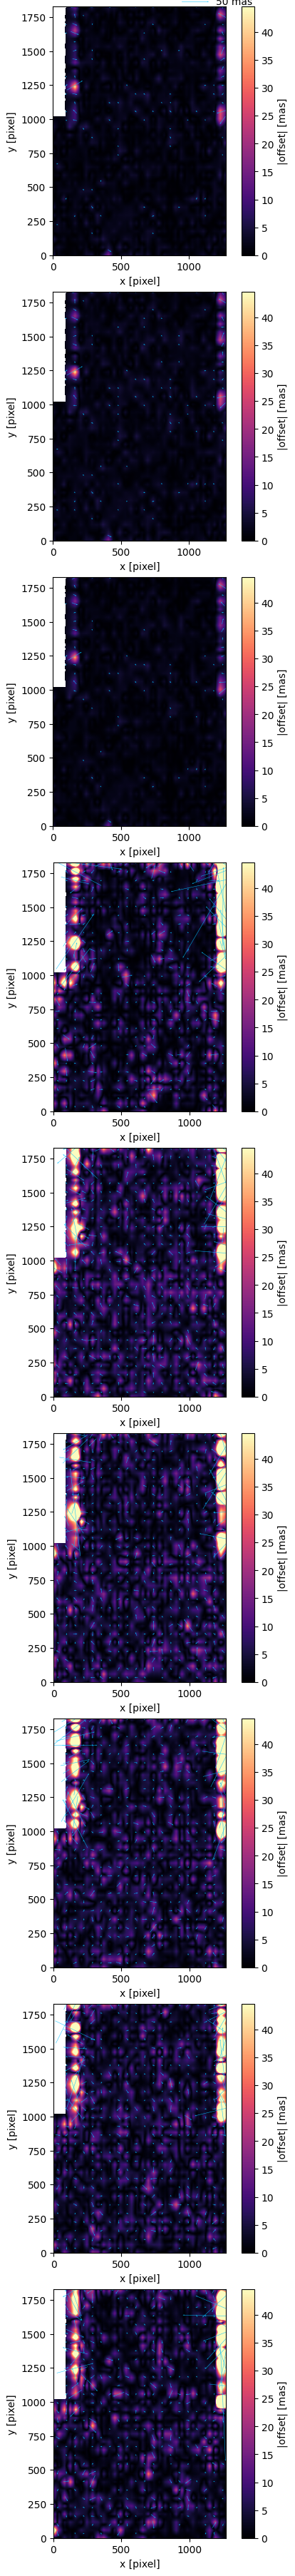

In [20]:
nrows = len(GROUP_NAMES)
fig, axes = plt.subplots(
    nrows,
    1,
    figsize=(12, 4 * nrows),
    constrained_layout=True,
    squeeze=False,
)

first_quiver = None

for row_idx, name in enumerate(GROUP_NAMES):
    ax = axes[row_idx, 0]
    entry = grouped[name]
    dra = entry["DRA"]["data"] * MAS_PER_ARCSEC
    dde = entry["DDE"]["data"] * MAS_PER_ARCSEC
    cov = entry["COV"]["data"] if "COV" in entry else None

    magnitude = offset_magnitude(dra, dde, cov)
    x, y, u, v = quiver_samples(
        dra,
        dde,
        cov,
        reference_mas=QUIVER_REF_MAS,
        min_mas=QUIVER_MIN_MAS,
    )

    ax.set_facecolor("white")
    im = ax.imshow(magnitude, cmap="magma", vmin=0.0, vmax=MAG_VMAX)
    if len(x):
        quiver = ax.quiver(x, y, u, v, **QUIVER_STYLE)
        if first_quiver is None:
            first_quiver = quiver

    #ax.set_title(f"{name} offset magnitude [mas] with quiver(DRA, DDE)")
    ax.set_xlabel("x [pixel]")
    ax.set_ylabel("y [pixel]")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="|offset| [mas]")

if first_quiver is not None:
    key_length = 50.0 / QUIVER_REF_MAS * QUIVER_ARROW_PIXELS
    axes[0, 0].quiverkey(first_quiver, X=0.9, Y=1.02, U=key_length, label="50 mas", labelpos="E")

plt.show()


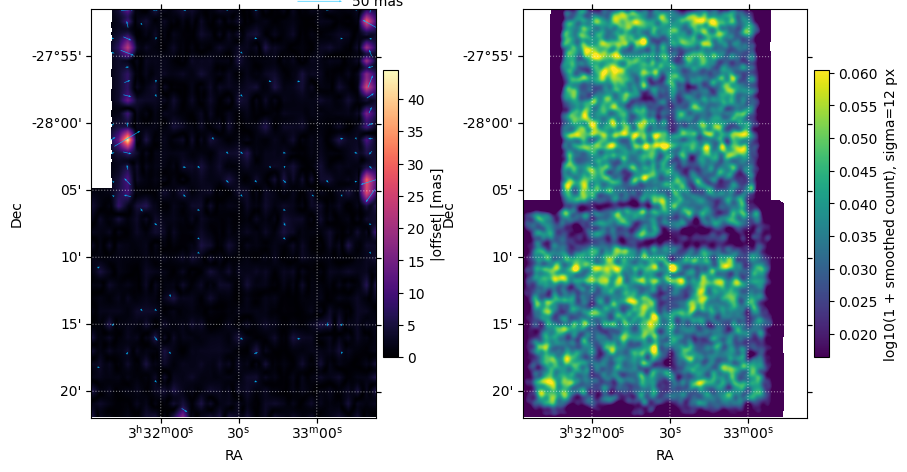

In [26]:
GROUP = GROUP_NAMES[0]  # Change this to another key from GROUP_NAMES.

entry = grouped[GROUP]
wcs = WCS(entry["DRA"]["header"])
dra = entry["DRA"]["data"] * MAS_PER_ARCSEC
dde = entry["DDE"]["data"] * MAS_PER_ARCSEC
cov = entry["COV"]["data"] if "COV" in entry else None

magnitude = offset_magnitude(dra, dde, cov)
x, y, u, v = quiver_samples(
    dra,
    dde,
    cov,
    reference_mas=QUIVER_REF_MAS,
    min_mas=QUIVER_MIN_MAS,
)
density_map, cached, n_in_frame = source_density_map(entry, GROUP)

fig = plt.figure(figsize=(10.2, 5.3))
ax1 = fig.add_subplot(1, 2, 1, projection=wcs)
ax2 = fig.add_subplot(1, 2, 2, projection=wcs)

for ax in (ax1, ax2):
    ax.set_facecolor("white")
    ax.coords.grid(color="white", ls=":", alpha=0.5)
    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")

im1 = ax1.imshow(magnitude, cmap="magma", vmin=0.0, vmax=MAG_VMAX)
quiver = None
if len(x):
    quiver = ax1.quiver(x, y, u, v, **QUIVER_STYLE)

#ax1.set_title(f"{GROUP} offset magnitude [mas] with quiver(DRA, DDE)")
if quiver is not None:
    key_length = 50.0 / QUIVER_REF_MAS * QUIVER_ARROW_PIXELS
    ax1.quiverkey(quiver, X=0.88, Y=1.02, U=key_length, label="50 mas", labelpos="E")
plt.colorbar(im1, ax=ax1, fraction=0.04, pad=0.02, label="|offset| [mas]")

if density_map is None:
    ax2.text(0.5, 0.5, "No cached source points available", ha="center", va="center", transform=ax2.transAxes)
else:
    density_log = np.ma.log10(density_map + 1.0)
    density_vals = finite_values(density_log)
    density_vals = density_vals[density_vals > 0]
    if density_vals.size:
        density_vmin = float(np.percentile(density_vals, DENSITY_RANGE_LO_PCT))
        density_vmax = float(np.percentile(density_vals, DENSITY_RANGE_HI_PCT))
        if density_vmax <= density_vmin:
            density_vmin = 0.0
            density_vmax = max(0.5, float(density_vals.max()))
    else:
        density_vmin, density_vmax = 0.0, 1.0
    im2 = ax2.imshow(density_log, cmap="viridis", vmin=density_vmin, vmax=density_vmax)
    n_used = 0 if cached is None else cached["n_used"]
    #ax2.set_title(
    #    f"{GROUP} density of cached fit points ({n_in_frame:,}/{n_used:,} in frame)"
    #)
    plt.colorbar(
        im2,
        ax=ax2,
        fraction=0.04,
        pad=0.02,
        label=f"log10(1 + smoothed count), sigma={DENSITY_SIGMA_PX:.0f} px",
    )

plt.show()
